## Load data

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

clinical_gex = pd.read_csv('../dataset/created/clinical_gex/clinical_gex_w_target.csv')
clinical_gex.head()

/var/folders/cy/vstztct90b90zhd8ssbmwpgh0000gn/T/ipykernel_39381/2589423427.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_gex = pd.read_csv('../dataset/created/clinical_gex/clinical_gex_w_target.csv')


,Unnamed: 0,patientID,sex,age,AJCC_stage,M_stage,LDH,drug,BOR,BRAF_mut,...,DCLK1,CENPL,FZD1,UBE2A,FBN2,KIAA1586,CLIC5,HAUS6,MIRLET7D,pfs_label
0,0,YR_3053,male,26,IV,M1B,elevated,vemurafenib,PD,V600E,...,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989,0
1,1,YR_3708,female,58,IV,M1A,normal,vemurafenib,CR,V600E,...,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637,2
2,2,YR_3705,male,45,IV,M1A,normal,vemurafenib,CR,V600E,...,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986,2
3,3,YR_1106,male,48,IIIC,NaN,normal,vemurafenib + cobimetinib,PD,V600E,...,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784,0
4,4,YR_1110,male,33,IV,M1C,normal,vemurafenib + cobimetinib,PD,V600E,...,6.090802,5.392477,5.643715,7.197660,4.979833,4.879302,4.011350,4.533517,5.500480,0


In [54]:
INCLUDE_BOR = False

if INCLUDE_BOR == False:
    clinical_gex = clinical_gex.drop(['BOR'], axis=1)

In [55]:
y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'Unnamed: 0', 'sample_id', 'source'], axis=1)
x.head()

,sex,age,AJCC_stage,M_stage,LDH,drug,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,...,FER,DCLK1,CENPL,FZD1,UBE2A,FBN2,KIAA1586,CLIC5,HAUS6,MIRLET7D
0,male,26,IV,M1B,elevated,vemurafenib,V600E,NaN,no,no,...,4.848412,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989
1,female,58,IV,M1A,normal,vemurafenib,V600E,NaN,no,no,...,5.229689,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637
2,male,45,IV,M1A,normal,vemurafenib,V600E,NaN,no,no,...,5.188426,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986
3,male,48,IIIC,NaN,normal,vemurafenib + cobimetinib,V600E,NaN,no,no,...,4.883034,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784
4,male,33,IV,M1C,normal,vemurafenib + cobimetinib,V600E,NaN,no,no,...,5.025112,6.090802,5.392477,5.643715,7.197660,4.979833,4.879302,4.011350,4.533517,5.500480


In [56]:
drug_dummies = x['drug'].str.get_dummies(sep='+')
x = pd.concat([x.drop('drug', axis=1), drug_dummies], axis=1)
x.head()

,sex,age,AJCC_stage,M_stage,LDH,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,Method,...,KIAA1586,CLIC5,HAUS6,MIRLET7D,cobimetinib,trametinib,dabrafenib,dabrafenib,vemurafenib,vemurafenib
0,male,26,IV,M1B,elevated,V600E,NaN,no,no,RNA-seq,...,4.600878,3.988906,4.463209,4.004989,0,0,0,0,1,0
1,female,58,IV,M1A,normal,V600E,NaN,no,no,RNA-seq,...,4.659288,3.988537,4.603643,4.324637,0,0,0,0,1,0
2,male,45,IV,M1A,normal,V600E,NaN,no,no,RNA-seq,...,5.028254,3.996558,4.800874,4.348986,0,0,0,0,1,0
3,male,48,IIIC,NaN,normal,V600E,NaN,no,no,RNA-seq,...,4.623254,3.996295,4.441287,4.777784,1,0,0,0,0,1
4,male,33,IV,M1C,normal,V600E,NaN,no,no,RNA-seq,...,4.879302,4.011350,4.533517,5.500480,1,0,0,0,0,1


In [57]:
braf_mut_dummies = x['BRAF_mut'].str.get_dummies(sep=';')
x = pd.concat([x.drop('BRAF_mut', axis=1), braf_mut_dummies], axis=1)
x.head()

,sex,age,AJCC_stage,M_stage,LDH,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,Method,CEBPZ,...,cobimetinib,trametinib,dabrafenib,dabrafenib,vemurafenib,vemurafenib,MND,V600E,V600K,V600R
0,male,26,IV,M1B,elevated,NaN,no,no,RNA-seq,6.955717,...,0,0,0,0,1,0,0,1,0,0
1,female,58,IV,M1A,normal,NaN,no,no,RNA-seq,6.903313,...,0,0,0,0,1,0,0,1,0,0
2,male,45,IV,M1A,normal,NaN,no,no,RNA-seq,7.303079,...,0,0,0,0,1,0,0,1,0,0
3,male,48,IIIC,NaN,normal,NaN,no,no,RNA-seq,6.563531,...,1,0,0,0,0,1,0,1,0,0
4,male,33,IV,M1C,normal,NaN,no,no,RNA-seq,6.741286,...,1,0,0,0,0,1,0,1,0,0


## Preprocessed Clinical data

In [58]:
m_stage_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['M1A', 'M1B', 'M1C']],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

bor_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['PD', 'SD', 'PR', 'CR']],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

other_feat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

if INCLUDE_BOR == True:
    preprocessor = ColumnTransformer(transformers=[
        ('m_stage_prep', m_stage_prep, ['M_stage']),
        ('bor_prep', bor_prep, ['BOR']),
        ('other_feat_prep', other_feat_prep, ['sex', 'AJCC_stage', 'LDH', 'brain_metastasis', 'immunotherapy_treatment', 'pre_MAPKi_treatment', 'Method'])
    ], remainder='passthrough')
else:
    preprocessor = ColumnTransformer(transformers=[
        ('m_stage_prep', m_stage_prep, ['M_stage']),
        ('other_feat_prep', other_feat_prep, ['sex', 'AJCC_stage', 'LDH', 'brain_metastasis', 'immunotherapy_treatment', 'pre_MAPKi_treatment', 'Method'])
    ], remainder='passthrough')

preprocessor.set_output(transform='pandas')

x_processed = preprocessor.fit_transform(x)
x_processed.head()

,m_stage_prep__M_stage,other_feat_prep__sex_female,other_feat_prep__sex_male,other_feat_prep__AJCC_stage_IIIC,other_feat_prep__AJCC_stage_IV,other_feat_prep__LDH_elevated,other_feat_prep__LDH_normal,other_feat_prep__brain_metastasis_no,other_feat_prep__brain_metastasis_yes,other_feat_prep__immunotherapy_treatment_no,...,remainder__ cobimetinib,remainder__ trametinib,remainder__dabrafenib,remainder__dabrafenib,remainder__vemurafenib,remainder__vemurafenib,remainder__MND,remainder__V600E,remainder__V600K,remainder__V600R
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0,0,0,0,1,0,0,1,0,0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0,0,0,0,1,0,0,1,0,0
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0,0,0,0,1,0,0,1,0,0
3,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1,0,0,0,0,1,0,1,0,0
4,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1,0,0,0,0,1,0,1,0,0


## Feature selection


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif, RFECV
from xgboost import XGBClassifier

# OHE columns have double underscores from ColumnTransformer naming convention
ohe_cols = [c for c in x_processed.columns if '__' in c and 
            any(c.startswith(p) for p in ['other_feat_prep', 'm_stage_prep', 'bor_prep'])]

numerical_cols = [c for c in x_processed.columns if c not in ohe_cols]

# --- Apply VarianceThreshold only to numerical (GEX) columns ---
selector = VarianceThreshold(threshold=0.90)
selector.set_output(transform='pandas')

x_num_thresholded = selector.fit_transform(x_processed[numerical_cols])

# --- Recombine with categorical columns ---
x_thresholded = pd.concat([x_processed[ohe_cols], x_num_thresholded], axis=1)

print(f'Original shape:    {x_processed.shape}')
print(f'Numerical before:  {len(numerical_cols)}')
print(f'Numerical after:   {x_num_thresholded.shape[1]}')
print(f'Reduced shape:     {x_thresholded.shape}')

Original shape:    (125, 13216)
Numerical before:  13203
Numerical after:   497
Reduced shape:     (125, 510)


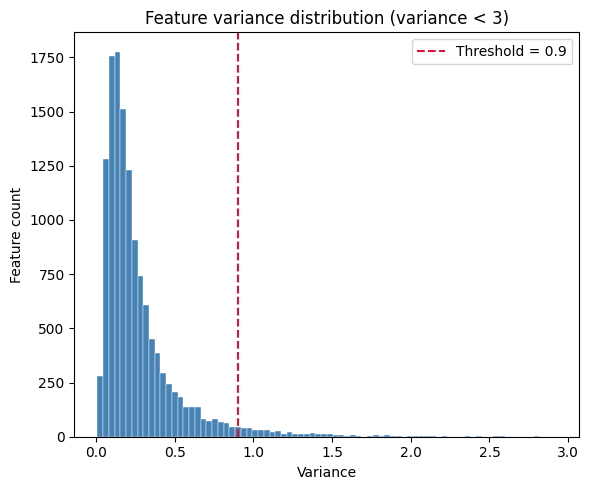

In [60]:
variances = selector.variances_
threshold = 0.90
cap = 3  # only show features with variance < cap

capped = variances[variances < cap]

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(capped, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(threshold, color='crimson', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
ax.set_xlabel('Variance')
ax.set_ylabel('Feature count')
ax.set_title(f'Feature variance distribution (variance < {cap})')
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
clf = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=clf, cv=cv_split, scoring='f1_macro', n_jobs=-1, step=1)

x_rfe = rfecv.fit_transform(x_thresholded, y)
print('Optimal number of features :', rfecv.n_features_)
print(f"Optimal features: {list(rfecv.get_feature_names_out())}")

Optimal number of features : 320
Optimal features: ['m_stage_prep__M_stage', 'remainder__age', 'remainder__CYBB', 'remainder__TSPAN7', 'remainder__CPN1', 'remainder__LGALS3', 'remainder__RNF182', 'remainder__CTSK', 'remainder__AKR1C3', 'remainder__ERRFI1', 'remainder__SFRP4', 'remainder__PLEKHB1', 'remainder__TMEM163', 'remainder__CD74', 'remainder__CITED1', 'remainder__BCHE', 'remainder__F13A1', 'remainder__IL1RAPL1', 'remainder__GSTM1', 'remainder__SLC24A5', 'remainder__CDKN2A', 'remainder__HOOK1', 'remainder__CA8', 'remainder__CORO2B', 'remainder__ENPP2', 'remainder__ABCC2', 'remainder__PCDHB2', 'remainder__LY6E', 'remainder__PRDM7', 'remainder__GPC4', 'remainder__SPINK5', 'remainder__THBS1', 'remainder__HKDC1', 'remainder__EMILIN1', 'remainder__PIR', 'remainder__MAGEC2', 'remainder__CXCL11', 'remainder__CCL4L1', 'remainder__SEMA3B', 'remainder__HOXB2', 'remainder__CTSB', 'remainder__SEMA6A', 'remainder__PDK4', 'remainder__SEMA5A', 'remainder__TYRP1', 'remainder__S100A8', 'remainder

In [62]:
selected_features = rfecv.get_feature_names_out()
importances = rfecv.estimator_.feature_importances_

ranked = sorted(zip(selected_features, importances), key=lambda x: x[1], reverse=True)
for feat, imp in ranked:
    print(f"{feat.split('__')[-1]}: {imp:.4f}")


MAGEA1: 0.0151
CDH2: 0.0140
TSPAN10: 0.0131
SCRG1: 0.0130
CD79A: 0.0124
STC1: 0.0105
M_stage: 0.0103
FAM178B: 0.0101
TFAP2A: 0.0094
IL1RAPL1: 0.0094
EGFL8: 0.0091
PLA1A: 0.0089
NTNG1: 0.0085
CCL14: 0.0084
CDKN2A: 0.0081
CSAG1: 0.0080
MIA: 0.0080
PAEP: 0.0078
FXYD3: 0.0074
MAGEA12: 0.0070
HMOX1: 0.0070
STRA6: 0.0069
LHX2: 0.0068
S100B: 0.0066
COL15A1: 0.0065
HPGD: 0.0063
COL10A1: 0.0059
CD3E: 0.0057
COL9A1: 0.0057
SCARNA4: 0.0056
C2: 0.0055
TUBB3: 0.0055
ALDH3B2: 0.0054
SNORA26: 0.0054
S100A8: 0.0054
WFDC1: 0.0053
PYGL: 0.0052
TFF3: 0.0052
APOC1: 0.0052
VGF: 0.0051
SERPINA5: 0.0051
IFI6: 0.0051
XIST: 0.0051
DSG1: 0.0050
SEMA3B: 0.0050
COL9A2: 0.0050
SEMA6A: 0.0050
P2RX7: 0.0049
IL32: 0.0049
SPARCL1: 0.0049
ITGA10: 0.0048
FLG2: 0.0047
CA14: 0.0047
TSPAN7: 0.0046
TTR: 0.0046
SLC16A6: 0.0046
SNORA68: 0.0046
LGI4: 0.0045
GPR143: 0.0045
L1CAM: 0.0045
TAP1: 0.0045
IFI30: 0.0045
SEMA3C: 0.0045
GJA1: 0.0045
CRTAC1: 0.0045
TYRP1: 0.0044
H19: 0.0044
HBA1: 0.0044
IFI27: 0.0044
PRRX2: 0.0043
CDK2: 

In [63]:
x_rfe_df = pd.DataFrame(x_rfe, columns=rfecv.get_feature_names_out())
clinical_gex_rfe = pd.concat([x_rfe_df, y], axis=1)
clinical_gex_rfe.to_csv('../dataset/created/clinical_gex/clinical_gex_rfe_without_bor.csv')